**Notebook to explore Research Question 1** 

Do AI-Generated PRs incur higher downstream maintenance burden than human-generated PRs, controlling for project scale, domain, & task type? 

Core Hypothesis:

AI-Generated pull requests exhibit a higher downstream maintenance burden than human-generated pull requests.
The maintenance burden associated with AI-generated pull requests increases as project scale increases. 
The maintenance burden associated with AI-generated pull requests is lower in domains with well-structured or highly standardized development patterns (e.g., frontend or ML workflows) compared to lower-level system domains.

**Dataset Loading & Imports** 

In [49]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import statsmodels.formula.api as smf

In [27]:
df = pd.read_parquet('../results/rq1_main_frame.parquet')
df.head()

,id,number,title,body,agent,user_id,user,state,created_at,closed_at,...,pr_outcome,fix_resolution_time,fix_iteration_count,pr_size_loc,pr_additions,pr_deletions,fix_size,defect_count_90d,has_defect_90d,defect_density
0,3264933329,2911,Fix: Wait for all partitions in load_collectio...,## Summary\n\nFixes an issue where `load_colle...,Claude_Code,108661493,weiliu1031,closed,2025-07-26 02:59:01+00:00,2025-07-29 07:01:20+00:00,...,rejected,NaN,NaN,396.0,394.0,2.0,396.0,0,0,0.000000
1,3265640341,30,Add build staleness detection for debug CLI,## Summary\r\n\r\n Implements comprehensive b...,Claude_Code,7475,MSch,closed,2025-07-26 13:31:19+00:00,2025-07-26 13:37:22+00:00,...,accepted,NaN,NaN,407.0,298.0,109.0,NaN,1,1,0.002457
2,3265782173,17625,chore: remove HashedPostStateProvider trait,## Summary\r\n\r\n#17545 \r\n\r\nRemove the un...,Claude_Code,47593288,adust09,open,2025-07-26 15:02:48+00:00,NaT,...,open,NaN,NaN,221.0,53.0,168.0,NaN,0,0,0.000000
3,3231949586,32656,feat(swagger): Add Swagger annotations to Batc...,## Summary\nProgressive implementation of Swag...,Claude_Code,1236198,spbolton,open,2025-07-15 11:46:41+00:00,NaT,...,open,NaN,NaN,3247.0,2702.0,545.0,NaN,0,0,0.000000
4,3231950376,32657,feat(swagger): Add Swagger annotations to Batc...,## Summary\nProgressive implementation of Swag...,Claude_Code,1236198,spbolton,open,2025-07-15 11:46:57+00:00,NaT,...,open,NaN,NaN,13888.0,12061.0,1827.0,NaN,0,0,0.000000


**Overall Maintenance Signals** 

P(defect | AI)
Avg defect_density
Avg resolution time
Avg fix size

0 - Human
1 - AI 

In [28]:
df.groupby("ai_pr")[[
    "has_defect_90d",
    "defect_density",
    "time_to_resolution",
    "pr_size_loc",
    "fix_size",
    "fix_resolution_time"
]].mean()

,has_defect_90d,defect_density,time_to_resolution,pr_size_loc,fix_size,fix_resolution_time
ai_pr,,,,,,
0,0.275841,0.059498,93.467490,1487.511189,778.366213,55.533557
1,0.197689,0.019432,78.799931,5013.797718,3832.443373,43.637134


In [ ]:
# Number of Defect PRs in Dataset 
df["has_defect_90d"].sum()

np.int64(4258)

In [ ]:
# Number of Defect PRs by ai_pr
df[df.has_defect_90d == 1].groupby("ai_pr").size()


ai_pr
0    1812
1    2446
dtype: int64

**Check Distribution Shapes** 

Histogram of pr_size_loc

Histogram of time_to_resolution

Histogram of defect_density

<Axes: title={'center': 'Histogram of PR Size (LOC)'}, ylabel='Frequency'>

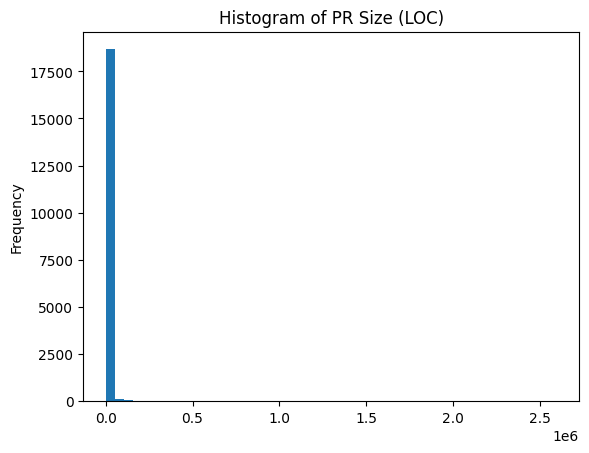

In [29]:
df["pr_size_loc"].plot(kind="hist", bins=50, title="Histogram of PR Size (LOC)")

<Axes: title={'center': 'Histogram of Log(PR Size + 1)'}, ylabel='Frequency'>

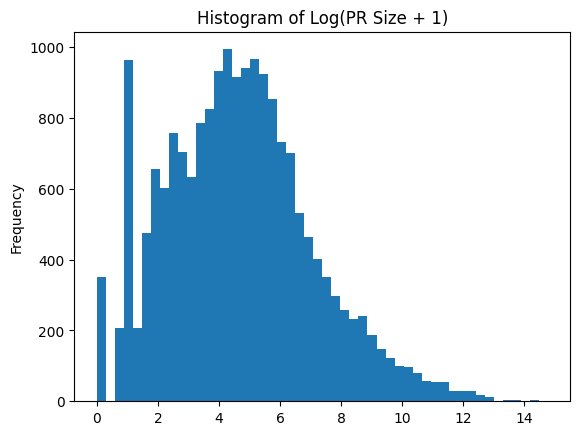

In [30]:
transformed_pr_size_loc = df["pr_size_loc"].dropna().pipe(pd.Series).apply(lambda x: np.log1p(x))
transformed_pr_size_loc.plot(kind="hist", bins=50, title="Histogram of Log(PR Size + 1)")

<Axes: title={'center': 'Histogram of Time to Resolution (days)'}, ylabel='Frequency'>

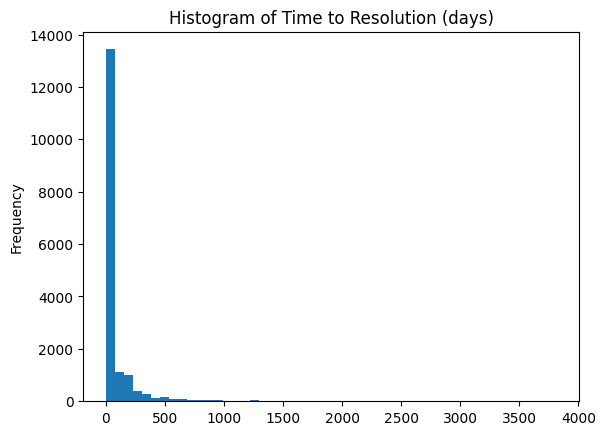

In [31]:
df["time_to_resolution"].plot(kind="hist", bins=50, title="Histogram of Time to Resolution (days)")

<Axes: title={'center': 'Histogram of Log(Time to Resolution + 1)'}, ylabel='Frequency'>

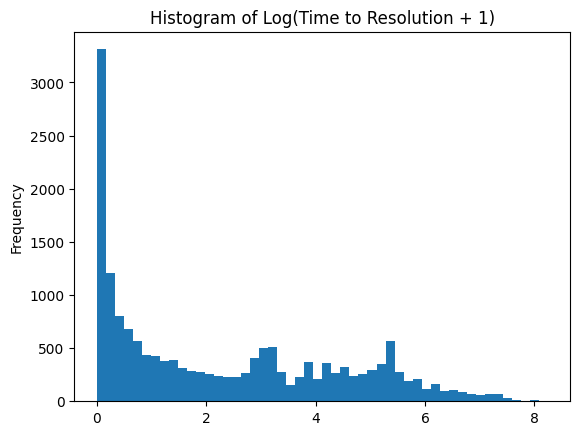

In [32]:
transformed_time_to_resolution = df["time_to_resolution"].dropna().pipe(pd.Series).apply(lambda x: np.log1p(x))
transformed_time_to_resolution.plot(kind="hist", bins=50, title="Histogram of Log(Time to Resolution + 1)")

<Axes: title={'center': 'Histogram of Defect Density (defects/LOC)'}, ylabel='Frequency'>

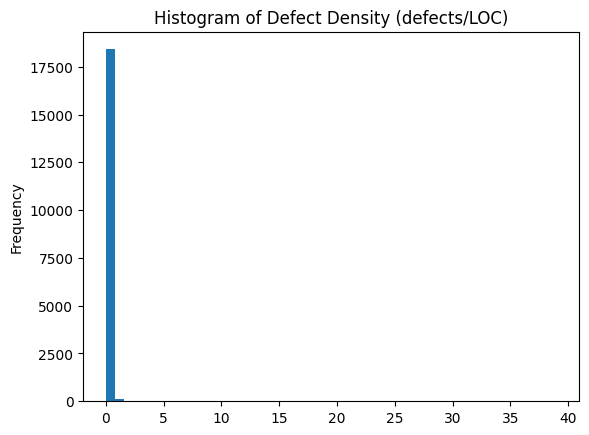

In [33]:
df["defect_density"].plot(kind="hist", bins=50, title="Histogram of Defect Density (defects/LOC)")

<Axes: title={'center': 'Histogram of Log(Defect Density + 1)'}, ylabel='Frequency'>

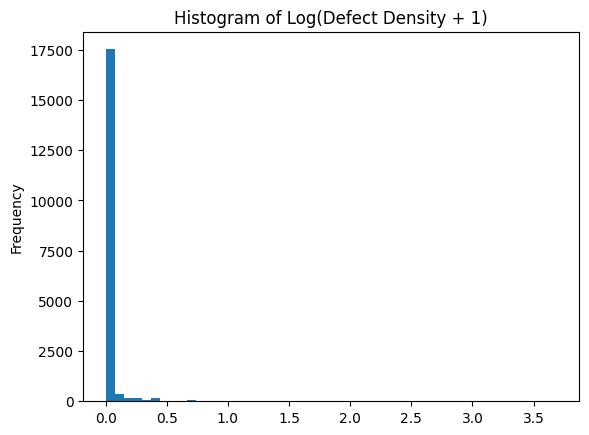

In [34]:
transformed_defect_density = df["defect_density"].dropna().pipe(pd.Series).apply(lambda x: np.log1p(x))
transformed_defect_density.plot(kind="hist", bins=50, title="Histogram of Log(Defect Density + 1)")

<Axes: title={'center': 'Histogram of Defect Count in 90 days'}, ylabel='Frequency'>

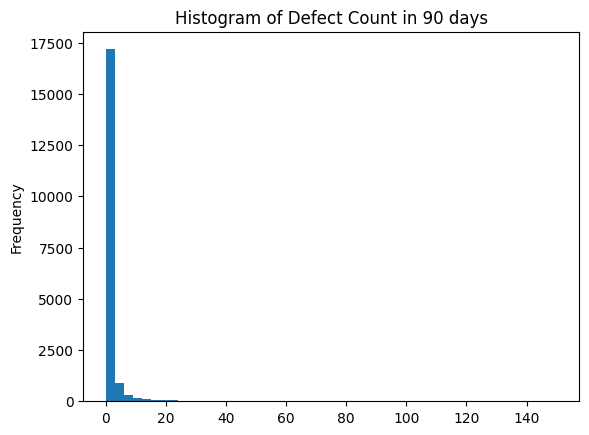

In [46]:
df["defect_count_90d"].plot(kind="hist", bins=50, title="Histogram of Defect Count in 90 days")

<Axes: title={'center': 'Histogram of Log(Defect Count + 1)'}, ylabel='Frequency'>

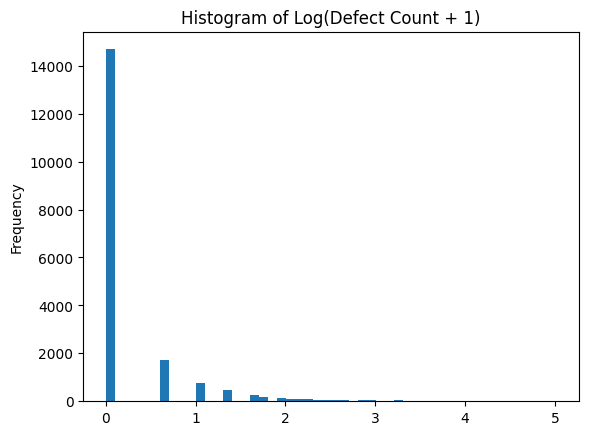

In [47]:
transformed_defect_count = df["defect_count_90d"].dropna().pipe(pd.Series).apply(lambda x: np.log1p(x))
transformed_defect_count.plot(kind="hist", bins=50, title="Histogram of Log(Defect Count + 1)")

**Stratified Descriptive Analysis** 

In [48]:
df.groupby("ai_pr")["defect_count_90d"].mean()

ai_pr
0    1.319379
1    0.865110
Name: defect_count_90d, dtype: float64

In [35]:
# Group by both star_group and ai_pr to see if there's an interaction effect
df.groupby(["star_group", "ai_pr"])["has_defect_90d"].mean()

star_group  ai_pr
0           0        0.263675
            1        0.215916
1           0        0.285320
            1        0.218086
2           0        0.274747
            1        0.165523
Name: has_defect_90d, dtype: float64

In [36]:
# Group by both star_group and ai_pr to see if there's an interaction effect
df.groupby(["star_group", "ai_pr"])["defect_density"].mean()

star_group  ai_pr
0           0        0.035301
            1        0.022694
1           0        0.041805
            1        0.023463
2           0        0.084050
            1        0.013306
Name: defect_density, dtype: float64

In [37]:
# Group by both star_group and ai_pr to see if there's an interaction effect
df.groupby(["star_group", "ai_pr"])["time_to_resolution"].mean()

star_group  ai_pr
0           0         77.100623
            1         55.862070
1           0         98.523187
            1         64.118090
2           0         97.598939
            1        109.681586
Name: time_to_resolution, dtype: float64

Does AI–Human gap widen as stars increase?

Results Explained: 

In [38]:
# Group by both age_group and ai_pr to see if there's an interaction effect
df.groupby(["age_group", "ai_pr"])["has_defect_90d"].mean()

age_group  ai_pr
0.0        0        0.355583
           1        0.275109
1.0        0        0.357744
           1        0.193188
2.0        0        0.229787
           1        0.165042
3.0        0        0.203170
           1        0.174361
Name: has_defect_90d, dtype: float64

In [39]:
# Group by both contributor_group and ai_pr to see if there's an interaction effect
df.groupby(["contributor_group", "ai_pr"])["has_defect_90d"].mean()
df.groupby(["contributor_group", "ai_pr"])["defect_density"].mean()

contributor_group  ai_pr
0                  0        0.011264
                   1        0.014244
1                  0        0.036882
                   1        0.023920
2                  0        0.147642
                   1        0.021404
Name: defect_density, dtype: float64

Does smaller or larger contributor groups effect performance? 

Results Explained:

In [40]:
# Group by both domain_type_group and ai_pr to see if there's an interaction effect
df.groupby(["domain_type_group", "ai_pr"])["has_defect_90d"].mean()

domain_type_group  ai_pr
0                  0        0.306831
                   1        0.222731
1                  0        0.274021
                   1        0.160683
2                  0        0.099526
                   1        0.115556
3                  0        0.177570
                   1        0.094808
4                  0        0.265049
                   1        0.213343
Name: has_defect_90d, dtype: float64

Does AI perform better in frontend/ML than systems?

Results explained:


In [45]:
df[df.task_type_group.isin([0, 2, 1, 3, 4])].groupby(
    ["task_type_group","ai_pr"]
)["has_defect_90d"].mean()

task_type_group  ai_pr
0.0              0        0.300311
                 1        0.208353
1.0              0        0.316893
                 1        0.179595
2.0              0        0.196117
                 1        0.165765
3.0              0        0.325203
                 1        0.280124
4.0              0        0.176796
                 1        0.180680
Name: has_defect_90d, dtype: float64

Are AI features, bug fixes, test, and refactors more error prone than documentation?

Results explained: 


After accounting for PR size, repo maturity (age), repo popularity (stars), team size (contributors), and differences across domains and task types, is a PR being AI-generated associated with a different probability of having at least one downstream fix within 90 days?

In [50]:
model = smf.logit(
    "has_defect_90d ~ ai_pr + np.log(pr_size_loc + 1) + repo_age_years + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.504735
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16023
Method:                           MLE   Df Model:                           13
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                 0.05464
Time:                        17:31:27   Log-Likelihood:                -8094.4
converged:                       True   LL-Null:                       -8562.3
Covariance Type:            nonrobust   LLR p-value:                1.092e-191
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.4884      0.068    -21.942      0.000      -1.

In [51]:
df.groupby("ai_pr")["pr_size_loc"].median()

ai_pr
0     56.0
1    121.0
Name: pr_size_loc, dtype: float64

AI-generated pull requests are associated with significantly lower short-term corrective maintenance burden compared to human-generated pull requests, after controlling for PR size, project maturity, contributor count, domain, and task type.

In [55]:
dfm = df.copy()

# Ensure numeric + finite where needed
dfm["log_pr_size"] = np.log(dfm["pr_size_loc"] + 1)
dfm["log_stars"]   = np.log(dfm["repo_stars"] + 1)

# Keep only rows that will be used by the model
needed = [
    "has_defect_90d", "ai_pr", "log_pr_size",
    "repo_age_years", "repo_stars", "log_stars",
    "contributor_count", "domain_type_group",
    "task_type_group", "repo_full_name"
]

dfm = dfm[needed].dropna()

# Also drop inf/-inf just in case (from log transforms)
dfm = dfm[np.isfinite(dfm["log_pr_size"]) & np.isfinite(dfm["log_stars"])].copy()

groups = dfm["repo_full_name"]

In [ ]:
#Does AI’s defect effect differ across domains?
m_domain = smf.logit(
    "has_defect_90d ~ ai_pr * C(domain_type_group) + log_pr_size + repo_age_years + repo_stars + contributor_count + C(task_type_group)",
    data=dfm
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups})

print(m_domain.summary())

                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16019
Method:                           MLE   Df Model:                           17
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                 0.05607
Time:                        17:59:06   Log-Likelihood:                -8082.2
converged:                       True   LL-Null:                       -8562.3
Covariance Type:              cluster   LLR p-value:                3.047e-193
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept                          -1.5071      0.231     -6.532      0.000      -1.959      -1.055
C(domain_type_group)[T.1]          -0.2631      0.266     -0.990    

In [57]:
#Does AI help less/more as PRs get larger?
m_size = smf.logit(
    "has_defect_90d ~ ai_pr * log_pr_size + repo_age_years + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=dfm
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups})

print(m_size.summary())


                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16022
Method:                           MLE   Df Model:                           14
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                 0.05520
Time:                        18:00:54   Log-Likelihood:                -8089.6
converged:                       True   LL-Null:                       -8562.3
Covariance Type:              cluster   LLR p-value:                8.203e-193
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.6889      0.283     -5.957      0.000      -2.245      -1.133
C(domain_type_group)[T.1]    -0.4555      0.228     -1.996      0.046      -0.903     

In [58]:
#Does the AI effect change with repo popularity/scale?
m_scale = smf.logit(
    "has_defect_90d ~ ai_pr * log_stars + log_pr_size + repo_age_years + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=dfm
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups})

print(m_scale.summary())


                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16022
Method:                           MLE   Df Model:                           14
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                 0.06062
Time:                        18:02:38   Log-Likelihood:                -8043.2
converged:                       True   LL-Null:                       -8562.3
Covariance Type:              cluster   LLR p-value:                1.007e-212
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.4325      0.536     -2.674      0.007      -2.483      -0.383
C(domain_type_group)[T.1]    -0.4306      0.227     -1.895      0.058      -0.876     

In [59]:
#Does the AI effect change as repos get older/more mature? 
m_age = smf.logit(
    "has_defect_90d ~ ai_pr * repo_age_years + log_pr_size + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=dfm
).fit(disp=0, cov_type="cluster", cov_kwds={"groups": groups})

print(m_age.summary())


                           Logit Regression Results                           
Dep. Variable:         has_defect_90d   No. Observations:                16037
Model:                          Logit   Df Residuals:                    16022
Method:                           MLE   Df Model:                           14
Date:                Wed, 11 Feb 2026   Pseudo R-squ.:                 0.05504
Time:                        18:03:20   Log-Likelihood:                -8091.0
converged:                       True   LL-Null:                       -8562.3
Covariance Type:              cluster   LLR p-value:                3.165e-192
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                    -1.4078      0.260     -5.416      0.000      -1.917      -0.898
C(domain_type_group)[T.1]    -0.4592      0.230     -1.997      0.046      -0.910     

| Hypothesis                             | Supported?   | Evidence                             |
| -------------------------------------- | ------------ | ------------------------------------ |
| AI increases maintenance burden        | ❌ Rejected   | AI coefficient consistently negative |
| AI burden increases with repo scale    | ❌ Rejected   | AI effect stronger in large repos    |
| AI burden increases with repo maturity | ❌ Rejected   | Interaction not significant          |
| AI varies by domain                    | ⚠️ Partially | Worse in Mobile                      |
| AI struggles with large PRs            | ❌ Rejected   | AI improves with size                |

AI-generated pull requests are associated with lower short-term corrective maintenance burden, particularly in large-scale repositories, though this advantage varies by domain.

In [61]:
dfm = df.copy()

dfm["log_pr_size"] = np.log(dfm["pr_size_loc"] + 1)
dfm["log_stars"]   = np.log(dfm["repo_stars"] + 1)

needed = [
    "defect_count_90d", "ai_pr", "log_pr_size",
    "repo_age_years", "repo_stars", "log_stars",
    "contributor_count", "domain_type_group",
    "task_type_group", "repo_full_name"
]

dfm = dfm[needed].dropna()
dfm = dfm[np.isfinite(dfm["log_pr_size"]) & np.isfinite(dfm["log_stars"])].copy()

groups = dfm["repo_full_name"].to_numpy()

In [64]:
import statsmodels.api as sm

poisson_model = smf.glm(
    "defect_count_90d ~ ai_pr + log_pr_size + repo_age_years + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=dfm,
    family=sm.families.Poisson()
).fit(cov_type="cluster", cov_kwds={"groups": groups})

print(poisson_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16023
Model Family:                 Poisson   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -32329.
Date:                Wed, 11 Feb 2026   Deviance:                       54384.
Time:                        18:16:24   Pearson chi2:                 1.11e+05
No. Iterations:                     7   Pseudo R-squ. (CS):             0.7218
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [65]:
mean_def = dfm["defect_count_90d"].mean()
var_def  = dfm["defect_count_90d"].var()

print("Mean:", mean_def)
print("Variance:", var_def)
print("Variance / Mean:", var_def / mean_def)


Mean: 1.0468292074577539
Variance: 20.187567427363383
Variance / Mean: 19.28449004244857


In [66]:
nb_model = smf.glm(
    "defect_count_90d ~ ai_pr + log_pr_size + repo_age_years + repo_stars + contributor_count + C(domain_type_group) + C(task_type_group)",
    data=dfm,
    family=sm.families.NegativeBinomial()
).fit(cov_type="cluster", cov_kwds={"groups": groups})

print(nb_model.summary())


/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16023
Model Family:        NegativeBinomial   Df Model:                           13
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18547.
Date:                Wed, 11 Feb 2026   Deviance:                       21613.
Time:                        18:17:17   Pearson chi2:                 4.89e+04
No. Iterations:                    11   Pseudo R-squ. (CS):             0.4075
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [67]:
nb_domain = smf.glm(
    "defect_count_90d ~ ai_pr * C(domain_type_group) + log_pr_size + repo_age_years + repo_stars + contributor_count + C(task_type_group)",
    data=dfm,
    family=sm.families.NegativeBinomial()
).fit(cov_type="cluster", cov_kwds={"groups": groups})

print(nb_domain.summary())


/Users/stevotrujillo/Desktop/CS260-MBILLMC/.venv/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:       defect_count_90d   No. Observations:                16037
Model:                            GLM   Df Residuals:                    16019
Model Family:        NegativeBinomial   Df Model:                           17
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18490.
Date:                Wed, 11 Feb 2026   Deviance:                       21499.
Time:                        18:18:18   Pearson chi2:                 4.82e+04
No. Iterations:                    12   Pseudo R-squ. (CS):             0.4117
Covariance Type:              cluster                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

| Model Type               | AI Effect                       | Significant? |
| ------------------------ | ------------------------------- | ------------ |
| Logistic (binary defect) | ↓ 42% odds                      | Yes          |
| Poisson                  | ↓ ~42% rate                     | Yes          |
| Negative Binomial        | ↓ ~38% rate                     | Yes          |
| NB + Domain Interaction  | ↓ overall, ↑ strongly in Mobile | Yes          |